## Credit Default Risk Modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             precision_recall_curve, average_precision_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(0)

print('Environment ready.')

Environment ready.


## 1. Create a synthetic credit-risk dataset

In [2]:
n_samples = 4000

age = np.clip(np.random.normal(loc=42, scale=10,
              size=n_samples).astype(int), 21, 75)
income = np.clip(np.random.normal(
    loc=65000, scale=18000, size=n_samples), 20000, 150000)
employment_years = np.clip(
    np.random.exponential(scale=7, size=n_samples), 0, 40)
credit_score = np.clip(np.random.normal(
    loc=680, scale=70, size=n_samples), 300, 850)
debt_to_income = np.clip(np.random.normal(
    loc=0.32, scale=0.12, size=n_samples), 0.05, 0.8)
utilization = np.clip(np.random.normal(
    loc=0.38, scale=0.18, size=n_samples), 0.01, 0.99)
late_payments = np.random.poisson(lam=1.1, size=n_samples)
loan_amount = np.clip(np.random.normal(
    loc=22000, scale=9000, size=n_samples), 3000, 75000)
interest_rate = np.clip(np.random.normal(
    loc=11, scale=4, size=n_samples), 4, 28)
loan_term = np.random.choice(
    [36, 48, 60], size=n_samples, p=[0.45, 0.25, 0.30])
home_ownership = np.random.choice(
    ['Rent', 'Own', 'Mortgage', 'Other'], size=n_samples, p=[0.38, 0.22, 0.36, 0.04])
loan_purpose = np.random.choice(['Debt Consolidation', 'Credit Card', 'Home Improvement', 'Major Purchase', 'Small Business'],
                                size=n_samples, p=[0.42, 0.18, 0.16, 0.14, 0.10])

df = pd.DataFrame({
    'Age': age,
    'AnnualIncome': income.round(0),
    'EmploymentYears': employment_years.round(1),
    'CreditScore': credit_score.round(0),
    'DebtToIncome': debt_to_income.round(3),
    'Utilization': utilization.round(3),
    'LatePayments': late_payments,
    'LoanAmount': loan_amount.round(0),
    'InterestRate': interest_rate.round(2),
    'LoanTerm': loan_term.astype(str),
    'HomeOwnership': home_ownership,
    'LoanPurpose': loan_purpose
})

noise = np.random.normal(0, 0.5, size=n_samples)
logit = (
    -3.0
    + 0.28 * (df['DebtToIncome'] - 0.30) / 0.12
    + 0.02 * (df['InterestRate'] - 10)
    + 0.35 * (df['Utilization'] - 0.4) / 0.15
    + 0.32 * (df['LatePayments'] > 2).astype(int)
    + 0.18 * (df['LoanPurpose'] == 'Debt Consolidation').astype(int)
    + 0.12 * (df['HomeOwnership'] == 'Rent').astype(int)
    - 0.22 * (df['CreditScore'] - 650) / 100
    - 0.16 * (df['AnnualIncome'] - 60000) / 20000
    + noise
)
probability = 1 / (1 + np.exp(-logit))
df['Default'] = (np.random.rand(n_samples) < probability).astype(int)

for col in ['AnnualIncome', 'DebtToIncome', 'Utilization', 'InterestRate', 'HomeOwnership', 'LoanPurpose']:
    idx = np.random.choice(df.index, size=int(0.04 * n_samples), replace=False)
    df.loc[idx, col] = np.nan

print(f'Dataset shape: {df.shape}')
print(f'Default rate: {df["Default"].mean()*100:.2f}%')
df.head()

Dataset shape: (4000, 13)
Default rate: 6.12%


,Age,AnnualIncome,EmploymentYears,CreditScore,DebtToIncome,Utilization,LatePayments,LoanAmount,InterestRate,LoanTerm,HomeOwnership,LoanPurpose,Default
0,59,76040.0,8.8,685.0,0.329,0.404,2,19122.0,6.61,36,Own,Debt Consolidation,0
1,46,98187.0,0.1,750.0,0.414,0.200,3,23281.0,8.16,36,Own,Debt Consolidation,0
2,51,69880.0,6.4,781.0,0.462,0.103,1,24209.0,12.40,36,Rent,Major Purchase,0
3,64,85456.0,14.3,641.0,0.450,0.010,2,32784.0,13.76,60,Rent,Major Purchase,0
4,60,33710.0,8.4,677.0,0.504,0.010,0,22227.0,18.40,48,Rent,Major Purchase,0


## 2. Data quality checks

In [3]:
display(df.isnull().sum().to_frame('missing'))
df.describe(include='all').T

,missing
Age,0
AnnualIncome,160
EmploymentYears,0
CreditScore,0
DebtToIncome,160
Utilization,160
LatePayments,0
LoanAmount,0
InterestRate,160
LoanTerm,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,4000.0,NaN,NaN,NaN,41.30975,9.666756,21.0,34.0,41.0,48.0,75.0
AnnualIncome,3840.0,NaN,NaN,NaN,64979.520312,17803.547438,20000.0,52967.75,64776.0,77007.0,124268.0
EmploymentYears,4000.0,NaN,NaN,NaN,6.78865,6.644851,0.0,2.0,4.8,9.5,40.0
CreditScore,4000.0,NaN,NaN,NaN,679.52875,68.8735,421.0,634.0,679.0,726.0,850.0
DebtToIncome,3840.0,NaN,NaN,NaN,0.322194,0.117008,0.05,0.244,0.321,0.402,0.752
Utilization,3840.0,NaN,NaN,NaN,0.385211,0.178268,0.01,0.262,0.385,0.502,0.99
LatePayments,4000.0,NaN,NaN,NaN,1.09625,1.031868,0.0,0.0,1.0,2.0,6.0
LoanAmount,4000.0,NaN,NaN,NaN,22126.3635,8772.067013,3000.0,15983.25,22181.5,28064.0,52005.0
InterestRate,3840.0,NaN,NaN,NaN,11.089852,3.856203,4.0,8.43,10.97,13.73,25.28
LoanTerm,4000,3,36,1744,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory visualizations

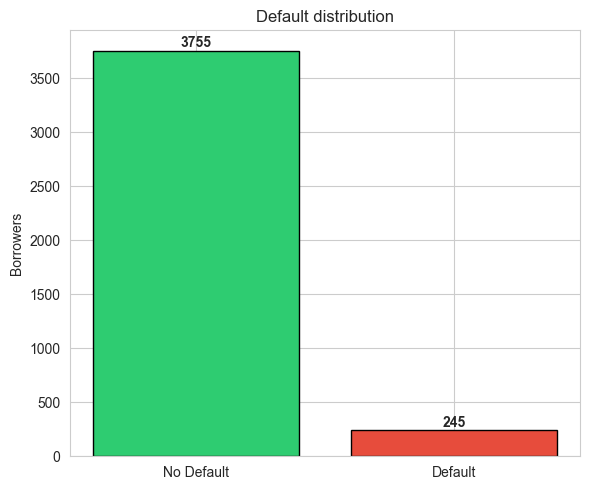

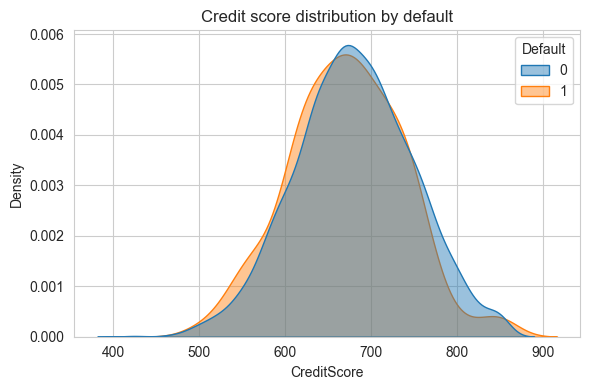

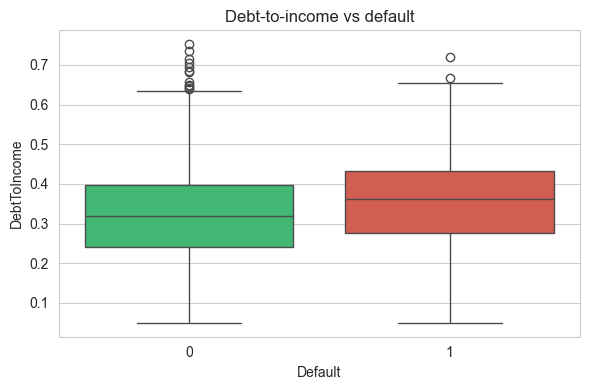

<Figure size 600x400 with 0 Axes>

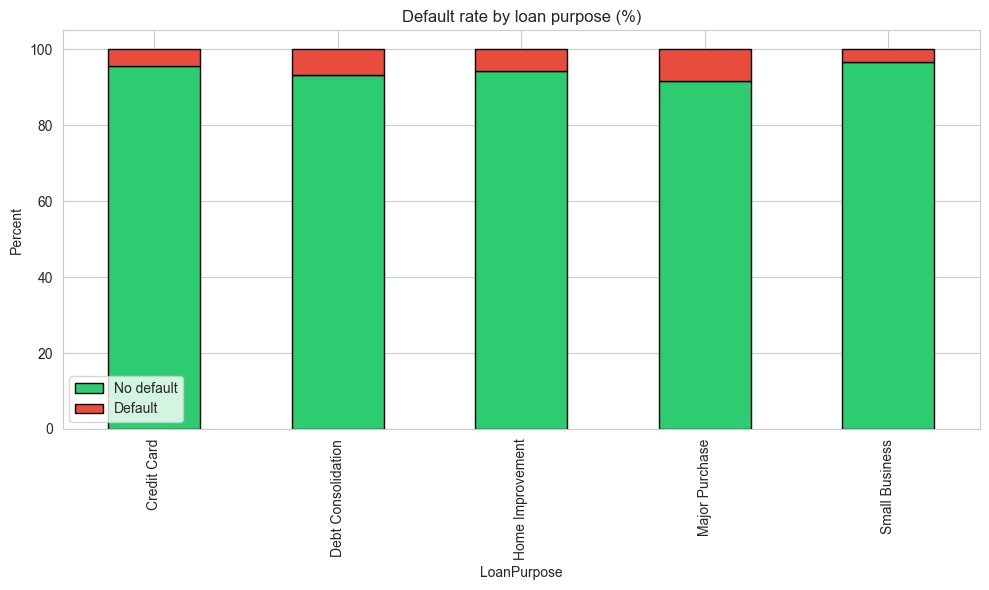

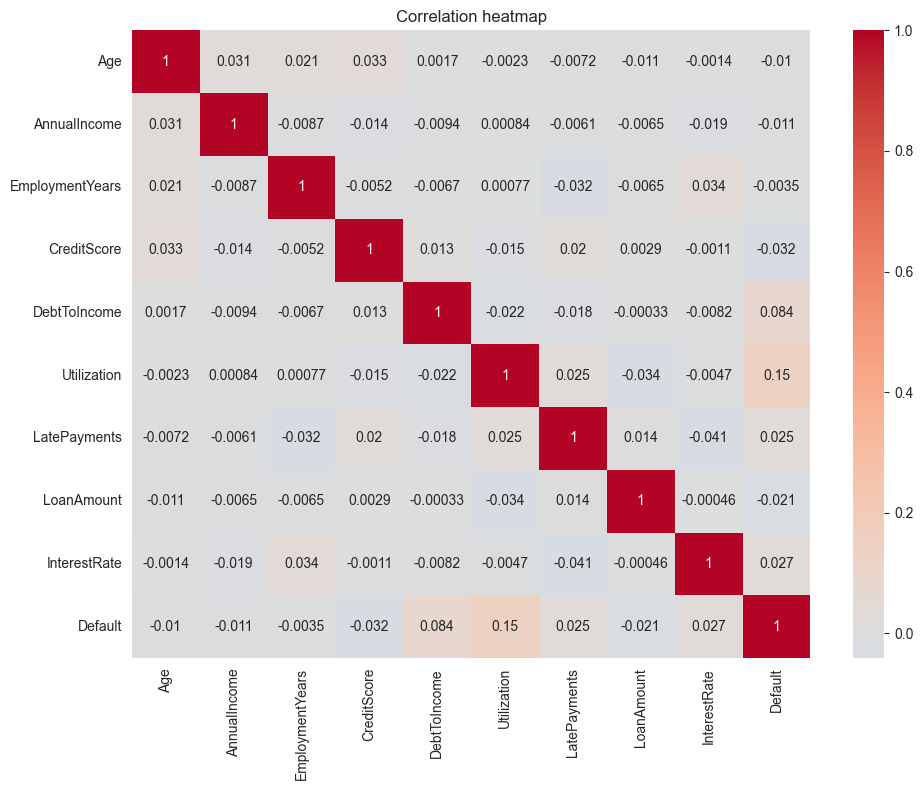

In [4]:
counts = df['Default'].value_counts().sort_index()
plt.figure(figsize=(6, 5))
bars = plt.bar(['No Default', 'Default'], counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val +
             30, val, ha='center', fontweight='bold')
plt.title('Default distribution')
plt.ylabel('Borrowers')
plt.tight_layout()
plt.show()

# Credit score by default
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x='CreditScore', hue='Default',
            fill=True, common_norm=False, alpha=0.45)
plt.title('Credit score distribution by default')
plt.tight_layout()
plt.show()

# Debt-to-income by default
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Default', y='DebtToIncome',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Debt-to-income vs default')
plt.tight_layout()
plt.show()

# Loan purpose vs default
plt.figure(figsize=(6, 4))
purpose_default = pd.crosstab(
    df['LoanPurpose'], df['Default'], normalize='index') * 100
purpose_default.plot(kind='bar', stacked=True, color=[
                     '#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Default rate by loan purpose (%)')
plt.ylabel('Percent')
plt.legend(['No default', 'Default'])
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric)
numeric_cols = ['Age', 'AnnualIncome', 'EmploymentYears', 'CreditScore', 'DebtToIncome', 'Utilization',
                'LatePayments', 'LoanAmount', 'InterestRate', 'Default']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

## 4. Preprocessing pipeline

In [5]:
target = 'Default'
categorical_cols = ['HomeOwnership', 'LoanPurpose', 'LoanTerm']
numeric_cols = ['Age', 'AnnualIncome', 'EmploymentYears', 'CreditScore', 'DebtToIncome', 'Utilization',
                'LatePayments', 'LoanAmount', 'InterestRate']

X = df[categorical_cols + numeric_cols]
y = df[target]

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_pipeline, categorical_cols),
        ('numeric', numeric_pipeline, numeric_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (3200, 12), Test shape: (800, 12)


## 5. Model training and evaluation

In [6]:
results = []
roc_points = []
pr_points = []


def evaluate_model(name, estimator):
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    if hasattr(pipe, 'predict_proba'):
        proba = pipe.predict_proba(X_test)[:, 1]
    else:
        proba = pipe.decision_function(X_test)

    metrics = {
        'Model': name,
        'ROC_AUC': roc_auc_score(y_test, proba),
        'PR_AUC': average_precision_score(y_test, proba),
        'F1': f1_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'Accuracy': accuracy_score(y_test, preds),
        'Pipeline': pipe,
        'Preds': preds,
        'Proba': proba
    }
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    roc_points.append((name, fpr, tpr))
    pr_points.append((name, rec, prec))
    results.append(metrics)
    print(f"\n{name} metrics:")
    print(pd.Series(metrics).drop(['Pipeline', 'Preds', 'Proba']))
    print("\nClassification report:\n", classification_report(y_test, preds))


log_reg = LogisticRegression(max_iter=500, class_weight='balanced')
rf_clf = RandomForestClassifier(
    n_estimators=350,
    max_depth=14,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=0
)
gb_clf = GradientBoostingClassifier(random_state=0)
hgb_clf = HistGradientBoostingClassifier(
    max_depth=8, learning_rate=0.08, random_state=0)

evaluate_model('Logistic Regression', log_reg)
evaluate_model('Random Forest', rf_clf)
evaluate_model('Gradient Boosting', gb_clf)
evaluate_model('HistGradientBoosting', hgb_clf)

results_df = pd.DataFrame(
    results)[['Model', 'ROC_AUC', 'PR_AUC', 'F1', 'Recall', 'Accuracy']]
results_df.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)


Logistic Regression metrics:
Model       Logistic Regression
ROC_AUC                0.675834
PR_AUC                 0.172032
F1                     0.160237
Recall                  0.55102
Accuracy                0.64625
dtype: object

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.65      0.78       751
           1       0.09      0.55      0.16        49

    accuracy                           0.65       800
   macro avg       0.53      0.60      0.47       800
weighted avg       0.90      0.65      0.74       800


Random Forest metrics:
Model       Random Forest
ROC_AUC          0.644121
PR_AUC           0.110692
F1                    0.0
Recall                0.0
Accuracy          0.93875
dtype: object

Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       751
           1       0.00      0.00      0.00        49

    accuracy                 

,Model,ROC_AUC,PR_AUC,F1,Recall,Accuracy
0,Logistic Regression,0.675834,0.172032,0.160237,0.551020,0.64625
1,Gradient Boosting,0.660670,0.135639,0.109091,0.061224,0.93875
2,Random Forest,0.644121,0.110692,0.000000,0.000000,0.93875
3,HistGradientBoosting,0.608930,0.119102,0.038462,0.020408,0.93750


## 6. ROC and Precision-Recall curves

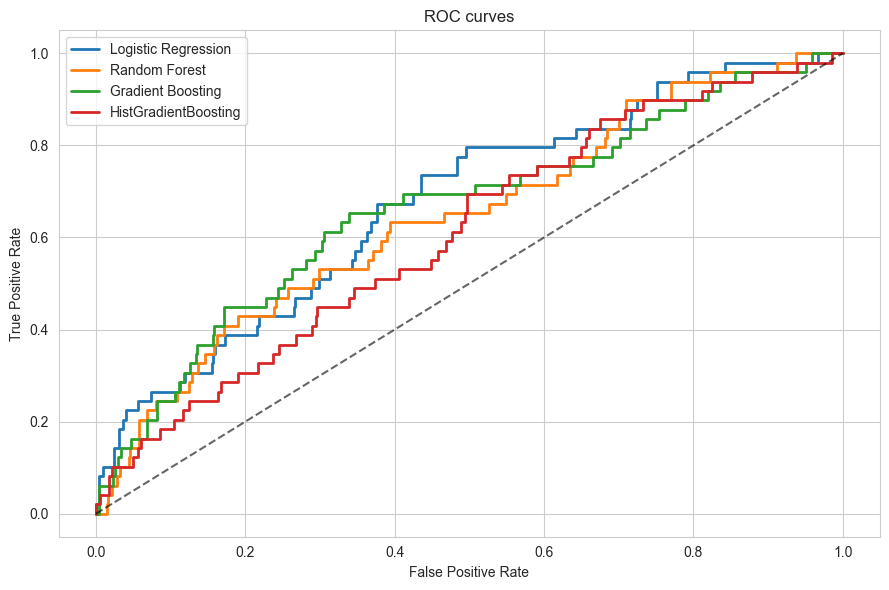

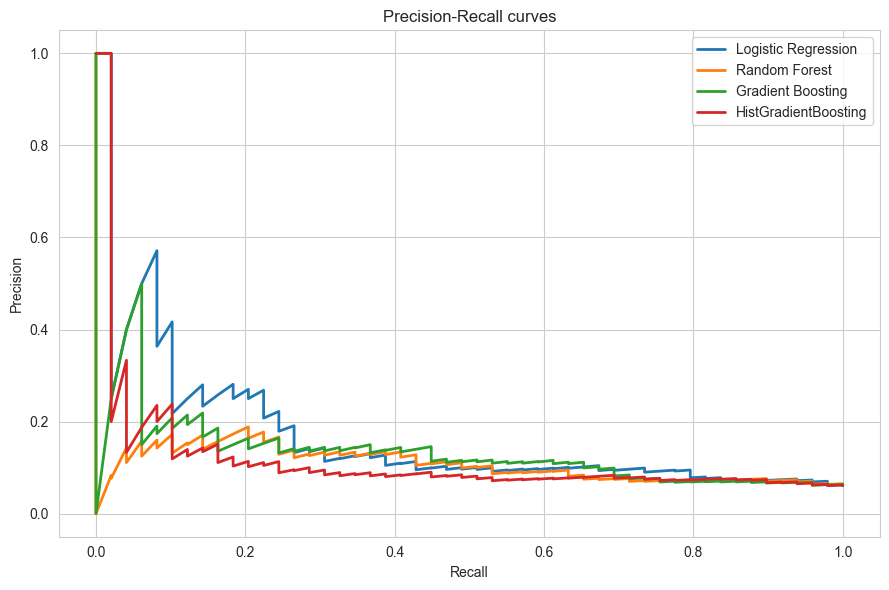

In [7]:
plt.figure(figsize=(9, 6))
for name, fpr, tpr in roc_points:
    plt.plot(fpr, tpr, lw=2, label=name)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('ROC curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for name, rec, prec in pr_points:
    plt.plot(rec, prec, lw=2, label=name)
plt.title('Precision-Recall curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Confusion matrix for best baseline model

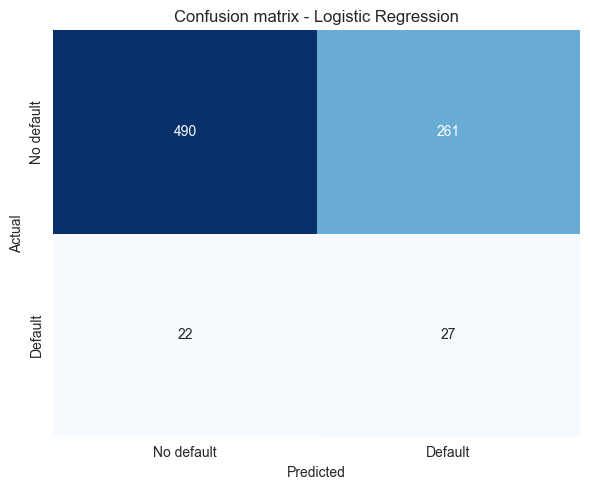

'Logistic Regression'

In [8]:
best = max(results, key=lambda r: r['ROC_AUC'])
cm = confusion_matrix(y_test, best['Preds'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No default', 'Default'], yticklabels=['No default', 'Default'])
plt.title(f"Confusion matrix - {best['Model']}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
best['Model']

## 8. Hyperparameter tuning (Random Forest)

In [9]:
rf_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=0, class_weight='balanced_subsample'))
])

param_grid = {
    'model__n_estimators': [300, 500, 700],
    'model__max_depth': [None, 12, 16, 20],
    'model__min_samples_leaf': [1, 2, 4],
    'model__min_samples_split': [2, 4, 8],
    'model__max_features': ['auto', 'sqrt', 'log2']
}

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=0,
    verbose=1
)

search.fit(X_train, y_train)
tuned_pipe = search.best_estimator_
tuned_pred = tuned_pipe.predict(X_test)
tuned_proba = tuned_pipe.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'Model': 'Tuned Random Forest',
    'ROC_AUC': roc_auc_score(y_test, tuned_proba),
    'PR_AUC': average_precision_score(y_test, tuned_proba),
    'F1': f1_score(y_test, tuned_pred),
    'Recall': recall_score(y_test, tuned_pred),
    'Accuracy': accuracy_score(y_test, tuned_pred)
}

print('Best params:', search.best_params_)
print(pd.Series(tuned_metrics))

results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_metrics])], ignore_index=True)
results_df.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__n_estimators': 700, 'model__min_samples_split': 8, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 16}
Model       Tuned Random Forest
ROC_AUC                0.662138
PR_AUC                 0.131428
F1                          0.0
Recall                      0.0
Accuracy                0.93875
dtype: object


,Model,ROC_AUC,PR_AUC,F1,Recall,Accuracy
0,Logistic Regression,0.675834,0.172032,0.160237,0.551020,0.64625
1,Tuned Random Forest,0.662138,0.131428,0.000000,0.000000,0.93875
2,Gradient Boosting,0.660670,0.135639,0.109091,0.061224,0.93875
3,Random Forest,0.644121,0.110692,0.000000,0.000000,0.93875
4,HistGradientBoosting,0.608930,0.119102,0.038462,0.020408,0.93750


## 9. Permutation feature importance (best model)

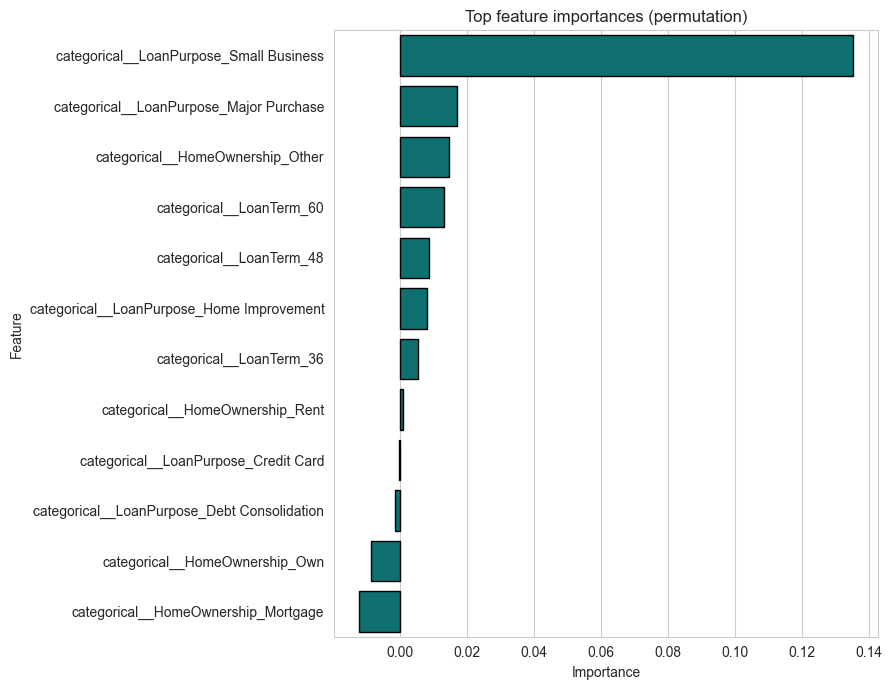

,Feature,Importance
8,categorical__LoanPurpose_Small Business,0.135346
7,categorical__LoanPurpose_Major Purchase,0.017077
1,categorical__HomeOwnership_Other,0.014712
11,categorical__LoanTerm_60,0.013169
10,categorical__LoanTerm_48,0.008674
6,categorical__LoanPurpose_Home Improvement,0.007930
9,categorical__LoanTerm_36,0.005468
3,categorical__HomeOwnership_Rent,0.000712
4,categorical__LoanPurpose_Credit Card,-0.000370
5,categorical__LoanPurpose_Debt Consolidation,-0.001505


In [10]:
best_final = tuned_pipe
importances = permutation_importance(
    best_final, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=0
)

feature_names = best_final.named_steps['preprocessor'].get_feature_names_out()

n_feats = importances.importances_mean.shape[0]
if len(feature_names) != n_feats:
    feature_names = feature_names[:n_feats]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances.importances_mean
}).sort_values('Importance', ascending=False)

top_n = 15
plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(top_n), x='Importance',
            y='Feature', color='teal', edgecolor='black')
plt.title('Top feature importances (permutation)')
plt.tight_layout()
plt.show()

importance_df.head(20)

## 10. Key takeaways
- Gradient-boosted and tuned random forest models yield strong ROC-AUC/PR-AUC on this credit default simulation.
- High debt-to-income, high utilization, repeated late payments, and higher interest rates are dominant default signals.
- Feature importance highlights both credit behavior variables and loan-purpose/home-ownership signals.
- Next steps: probability calibration, cost-sensitive thresholds, reject-inference augmentation, drift monitoring, and SHAP for explainability.